In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from joblib import Parallel, delayed

plt.style.use("~/Documents/mplstyles/paper.mplstyle")

In [ ]:
G = const.G.cgs
c = const.c.cgs

eos = np.loadtxt("eos.csv", skiprows=1, delimiter=",")

P_div_c2_orig = eos[:, 0] * u.g * u.cm**(-3)
eps_div_c2_orig = eos[:, 1] * u.g * u.cm**(-3)
baryon_density_orig = eos[:, 2] * u.g * u.cm**(-3)

1.1236019714159985e-13 g / cm3 6.69048771152622 g / cm3 7.75762126553246 g / cm3
491


In [3]:
def dP_dr(r, P, eps, m):
    if r == 0:
        f = 1 - (8 * np.pi * G * eps * r**2)/(3 * c**2)
        A = 4 * np.pi * r * G / f
        B = eps + P
        C = (eps / 3 + P)
    else:
        f = 1 - (2 * G * m) / (c**2 * r)
        A = G / (r**2 * f)
        B = (eps + P)
        C = (m + 4 * np.pi * r**3 * P)
    return -A * B * C

def dM_dr(r, eps):
    return 4 * np.pi * r**2 * (eps)

def tov_solver(P_div_c2_centre, dr=1 * u.m, save_array=True, method='RK4'):
    r0 = 0 * u.cm
    m0 = 0 * u.g

    if save_array:
        Ms = np.array([]) * u.g
        Rs = np.array([]) * u.cm
        P_div_c2s = np.array([]) * (u.g / u.cm**3)
        Rs = np.append(Rs, r0)
        Ms = np.append(Ms, m0)
        P_div_c2s = np.append(P_div_c2s, P_div_c2_centre)
        
    r = r0
    m = m0
    P_div_c2 = P_div_c2_centre

    keep_going = True
    R_max = 1e4 * u.km
    i=0

    while keep_going:
        i += 1
        old_r = r
        old_m = m
        old_P_div_c2 = P_div_c2

        idx = np.argmin(np.abs(old_P_div_c2 - P_div_c2_orig))
        old_eps_div_c2 = eps_div_c2_orig[idx]

        if method == "euler":
            # euler
            m_slope = dM_dr(old_r, old_eps_div_c2)
            P_slope = dP_dr(old_r, old_P_div_c2, old_eps_div_c2, old_m)

            m = old_m + m_slope * dr
            P_div_c2 = old_P_div_c2 + P_slope * dr * c**(-2)

        if method == "RK4":
            # RK4
            k1_m = dM_dr(old_r, old_eps_div_c2)
            k2_m = dM_dr(old_r + 0.5 * dr, old_eps_div_c2)
            k3_m = dM_dr(old_r + 0.5 * dr, old_eps_div_c2)
            k4_m = dM_dr(old_r + dr, old_eps_div_c2)

            k1_P = dP_dr(old_r, old_P_div_c2, old_eps_div_c2, old_m)
            k2_P = dP_dr(old_r + 0.5 * dr, old_P_div_c2 + 0.5 * k1_P * dr * c**(-2), old_eps_div_c2, old_m + 0.5 * k1_m * dr)
            k3_P = dP_dr(old_r + 0.5 * dr, old_P_div_c2 + 0.5 * k2_P * dr * c**(-2), old_eps_div_c2, old_m + 0.5 * k2_m * dr)
            k4_P = dP_dr(old_r + dr, old_P_div_c2 + k3_P * dr * c**(-2), old_eps_div_c2, old_m + k3_m * dr)

            m = old_m + (k1_m + 2 * k2_m + 2 * k3_m + k4_m) / 6 * dr
            P_div_c2 = old_P_div_c2 + (k1_P + 2 * k2_P + 2 * k3_P + k4_P) / 6 * dr * c**(-2)

        r = old_r + dr

        if save_array:
            Rs = np.append(Rs, r)
            Ms = np.append(Ms, m)
            P_div_c2s = np.append(P_div_c2s, P_div_c2)

        elif P_div_c2 < 0:
            keep_going = False
            # interpolate between two last pressure points
            x = np.linspace(old_r, r, 50)
            xp = np.array([old_r.value, r.value]) * r.unit
            fp = np.array([old_P_div_c2.value, P_div_c2.value]) * P_div_c2.unit
            P_div_c2_interp = np.interp(x, xp, fp)

            fp = np.array([old_m.value, m.value]) * m.unit
            M_interp = np.interp(x, xp, fp)

            P_zero_idx = np.argmin(np.abs(P_div_c2_interp))
            
            keep_going = False
            if save_array:
                Rs[-1] = x[P_zero_idx]
                Ms[-1] = M_interp[P_zero_idx]
                P_div_c2s[-1] = P_div_c2_interp[P_zero_idx]
                return Rs, Ms, P_div_c2s
            else:
                R = x[P_zero_idx]
                M = M_interp[P_zero_idx]
                return R, M


def plot_continuous_segments(ax, x_data, y_data, mask, color, label, line_plotted):
    # Find boundaries where the mask changes
    diff_mask = np.diff(np.concatenate(([False], mask, [False])).astype(int))
    starts = np.where(diff_mask == 1)[0]
    ends = np.where(diff_mask == -1)[0]
    
    for start, end in zip(starts, ends):
        if not line_plotted[0]:  # Only add label to first segment
            ax.plot(x_data[start:end], y_data[start:end], color=color, label=label)
            line_plotted[0] = True
        else:
            ax.plot(x_data[start:end], y_data[start:end], color=color)

In [ ]:
dr = 1 * u.m
P_div_c2_0_arr = np.logspace(np.log10(2e12), np.log10(1e17), 500) * (u.g / u.cm**3)

results = Parallel(n_jobs=-1, verbose=1, backend="loky")(
    delayed(tov_solver)(P_div_c2_0, dr, False, 'euler') 
    for P_div_c2_0 in P_div_c2_0_arr
)

Rs = np.zeros_like(P_div_c2_0_arr.value) * u.cm
Ms = np.zeros_like(P_div_c2_0_arr.value) * u.Msun

for i, (R, M) in enumerate(results):
    Rs[i] = R
    Ms[i] = M

print(f"Computed {len(results)} solutions")

res = np.column_stack((Rs.to(u.km).value, Ms.to(u.Msun).value, P_div_c2_0_arr.to(u.g / u.cm**3).value))

np.savetxt("results_new.csv", res, delimiter=",", header="R [km],M [Msun],P_div_c2 [g/cm^3]", comments="")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   32.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  4.6min


Computed 500 solutions


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  5.3min finished


In [101]:
data = np.loadtxt("results.csv", skiprows=1, delimiter=",")
Rs = data[:, 0] * u.km
Ms = data[:, 1] * u.Msun
P_div_c2_0_arr = data[:, 2] * (u.g / u.cm**3)

test_Ms = np.array([0, 3]) * u.Msun
R_schwarzchild = (2 * G * test_Ms / c**2).to(u.km)

M_ch_idx = np.where(np.isclose(Ms.to_value(u.Msun), 1.4, atol=0.003))[0]
R_ch = Rs[M_ch_idx].to(u.km)

In [ ]:
# first derivative of Ms and Rs
dM = np.gradient(Ms.to(u.Msun).value, P_div_c2_0_arr.to(u.g / u.cm**3).value)
dR = np.gradient(Rs.to(u.km).value, P_div_c2_0_arr.to(u.g / u.cm**3).value)

# find where dM and dR switch sign
dM_sign_change = np.where(np.diff(np.sign(dM)))[0]
dR_sign_change = np.where(np.diff(np.sign(dR)))[0]

# remove dR sign change points that are too close to eachother
print(dR_sign_change)
diff_dR = np.append(115, np.diff(dR_sign_change))
print(diff_dR)
dR_sign_change = dR_sign_change[diff_dR > 5]

# remove dM sign change points that are too close together
print(dM_sign_change)
diff_dM = np.append(115, np.diff(dM_sign_change))
print(diff_dM)


[115 117 118 184 306 310 312 484 485 487 488 489]
[115   2   1  66 122   4   2 172   1   2   1   1]
[187 203 268 307 335]
[115  16  65  39  28]


In [149]:
unstable_even_nodes = 1
unstable_odd_nodes = 1
unstable_nodes = unstable_even_nodes + unstable_odd_nodes
stability = np.ones_like(Ms.value, dtype=bool)

M_change_last = 0
print(unstable_even_nodes, unstable_odd_nodes, unstable_nodes)
for M_change in dM_sign_change:
    print("=============")
    if M_change_last == 0:
        # do nothing
        pass
    else:
        stability[M_change_last:M_change] = not bool(unstable_nodes)

    are_equal = unstable_even_nodes == unstable_odd_nodes 
    change_even = True
    this_dR = dR[M_change]
    change_even = False
    if this_dR < 0:
        change_even = True
    
    if change_even:  # do we alter even nodes
        if are_equal:  # if equal, existing unstable odd node prevents restabilizing
            unstable_even_nodes +=1
        else:
            unstable_even_nodes -=1
    else:  # do we alter odd nodes
        if are_equal:  # if equal, non-existent unstable even node prevents destabilizing
            unstable_odd_nodes -=1
        else:
            unstable_odd_nodes +=1

    unstable_nodes = unstable_even_nodes + unstable_odd_nodes
    print(unstable_even_nodes, unstable_odd_nodes, unstable_nodes)
    # stability[M_change_last:M_change] = not bool(unstable_nodes)
    M_change_last = M_change
stability[M_change_last:] = not bool(unstable_nodes)

1 1 2
2 1 3
1 1 2
2 1 3
2 2 4
2 1 3


/var/folders/6l/y2z2vm4913sb2lzhwp95z6q00000gn/T/ipykernel_72241/939013782.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


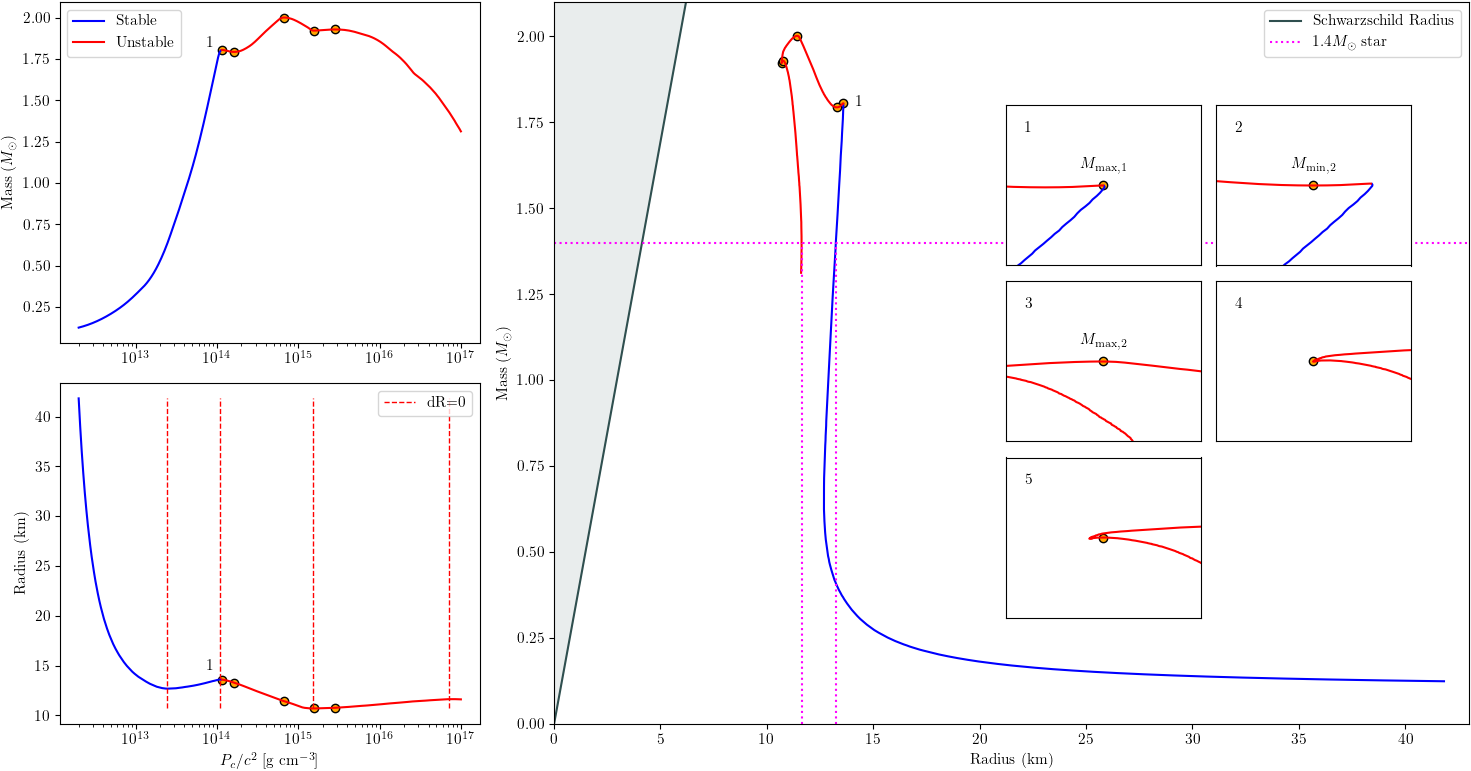

In [151]:
fig = plt.figure(figsize=(15, 8))

ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=1)  # Top left
ax2 = plt.subplot2grid((2, 3), (1, 0), colspan=1)  # Bottom left
ax3 = plt.subplot2grid((2, 3), (0, 1), colspan=2, rowspan=2)  # Right side spanning both rows

ax1.sharex(ax2)

P_c = P_div_c2_0_arr

# ======== Plot P_c vs R=M ==========
stable_plotted2 = [False]
unstable_plotted2 = [False]
plot_continuous_segments(ax1, P_c.to(u.g / u.cm**3), Ms.to(u.Msun), stability, 'blue', 'Stable', stable_plotted2)
plot_continuous_segments(ax1, P_c.to(u.g / u.cm**3), Ms.to(u.Msun), ~stability, 'red', 'Unstable', unstable_plotted2)
ax1.scatter(P_c[dM_sign_change].to(u.g / u.cm**3), Ms[dM_sign_change].to(u.Msun), c='orange', edgecolors='k', linewidths=1)
ax1.set_ylabel(r"Mass ($M_\odot$)")
ax1.legend()
ax1.text(0.35, 0.9, "1", ha='left', va='top', transform=ax1.transAxes)

# ======== Plot P_c vs R ==========
stable_plotted = [True]
unstable_plotted = [True]
plot_continuous_segments(ax2, P_c.to(u.g / u.cm**3), Rs.to(u.km), stability, 'blue', 'Stable', stable_plotted)
plot_continuous_segments(ax2, P_c.to(u.g / u.cm**3), Rs.to(u.km), ~stability, 'red', 'Unstable', unstable_plotted)

ax2.scatter(P_c[dM_sign_change].to(u.g / u.cm**3), Rs[dM_sign_change].to(u.km), c='orange', edgecolors='k', linewidths=1)
ax2.vlines(P_c[dR_sign_change].to(u.g / u.cm**3), ymin=np.min(Rs.to_value(u.km)), ymax=np.max(Rs.to_value(u.km)),
            colors='red', linestyles='dashed', linewidths=1, label='dR=0')
ax2.set_xscale('log')
ax2.set_xlabel(r"$P_c/c^2$ [g cm$^{-3}$]")
ax2.set_ylabel("Radius (km)")
ax2.text(0.35, 0.19, "1", ha='left', va='top', transform=ax2.transAxes)
ax2.legend()

# ======== Plot R vs M ==========
stable_plotted3 = [True]
unstable_plotted3 = [True]
plot_continuous_segments(ax3, Rs.to(u.km), Ms.to(u.Msun), stability, 'blue', 'Stable', stable_plotted3)
plot_continuous_segments(ax3, Rs.to(u.km), Ms.to(u.Msun), ~stability, 'red', 'Unstable', unstable_plotted3)
ax3.scatter(Rs[dM_sign_change].to(u.km), Ms[dM_sign_change].to(u.Msun), c='orange', edgecolors='k', linewidths=1)

ax3.plot(R_schwarzchild.to(u.km), test_Ms.to(u.Msun), c='darkslategrey', label='Schwarzschild Radius')
# shade to the left of R_schwarzchild
ax3.fill_betweenx(test_Ms.to_value(u.Msun), 0, R_schwarzchild.to_value(u.km), color='darkslategrey', alpha=0.1)
ax3.axhline(y=1.4, color='magenta', linestyle=':', label=r'$1.4M_\odot$ star')
ax3.vlines(R_ch.to(u.km), ymin=0, ymax=1.4, colors='magenta', linestyles=':')

ax3.set_xlabel("Radius (km)")
ax3.set_ylabel(r"Mass ($M_\odot$)")
ax3.set_xlim(0, 43)
ax3.set_ylim(0, 2.1)
ax3.text(0.33, 0.87, "1", ha='left', va='top', transform=ax3.transAxes)

for i in range(len(dM_sign_change)):
    j = i % 2
    k = i // 2
    ax_inset = fig.add_axes([0.68 + j*0.14, 0.65 - k*0.22, 0.13, 0.2])

    # ax_inset.plot(Rs.to(u.km), Ms.to(u.Msun))
    plot_continuous_segments(ax_inset, Rs.to(u.km), Ms.to(u.Msun), stability, 'blue', 'Stable', stable_plotted3)
    plot_continuous_segments(ax_inset, Rs.to(u.km), Ms.to(u.Msun), ~stability, 'red', 'Unstable', unstable_plotted3)
    
    this_R = Rs[dM_sign_change[i]].to(u.km)
    this_M = Ms[dM_sign_change[i]].to(u.Msun)
    ax_inset.scatter(this_R, this_M, c='orange', label='dM=0', edgecolors='k', linewidths=1)
    ax_inset.set_xlim(this_R.value - 0.5, this_R.value + 0.5)
    ax_inset.set_ylim(this_M.value - 0.5, this_M.value + 0.5)
    # turn axis ticks and labels off
    ax_inset.tick_params(axis='both', which='both', length=0)
    ax_inset.xaxis.set_tick_params(labelbottom=False)
    ax_inset.yaxis.set_tick_params(labelleft=False)
    # write the index of the point in the top left corner of the inset
    ax_inset.text(0.1, 0.9, str(i+1), ha='left', va='top', transform=ax_inset.transAxes)
    if i == 0:
        ax_inset.text(0.5, 0.62, r"$M_{\rm max, 1}$", ha='center', va='center', transform=ax_inset.transAxes)
    if i == 1:
        ax_inset.text(0.5, 0.62, r"$M_{\rm min, 2}$", ha='center', va='center', transform=ax_inset.transAxes)
    if i == 2:
        ax_inset.text(0.5, 0.62, r"$M_{\rm max, 2}$", ha='center', va='center', transform=ax_inset.transAxes)

ax3.legend()

plt.tight_layout()
# plt.savefig("tov_results.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
Ms_branch_1 = Ms[:dM_sign_change[0]]
Ms_branch_2 = Ms[dM_sign_change[1]:dM_sign_change[2]]
Rs_branch_1 = Rs[:dM_sign_change[0]]
Rs_branch_2 = Rs[dM_sign_change[1]:dM_sign_change[2]]
M_max1_idx = np.argmax(Ms_branch_1)
M_min1_idx = np.argmin(Ms_branch_1)
M_max2_idx = np.argmax(Ms_branch_2)
M_min2_idx = np.argmin(Ms_branch_2)

M_max1 = Ms_branch_1[M_max1_idx]
M_min1 = Ms_branch_1[M_min1_idx]
M_max2 = Ms_branch_2[M_max2_idx]
M_min2 = Ms_branch_2[M_min2_idx]

R_M_max1 = Rs_branch_1[M_max1_idx]
R_M_min1 = Rs_branch_1[M_min1_idx]
R_M_max2 = Rs_branch_2[M_max2_idx]
R_M_min2 = Rs_branch_2[M_min2_idx]

R14_1 = R_ch[0]
R14_2 = R_ch[1]

print("M_max1:", M_max1, "R_M_max1:", R_M_max1)
print("M_min1:", M_min1, "R_M_min1:", R_M_min1)
print("M_max2:", M_max2, "R_M_max2:", R_M_max2)
print("M_min2:", M_min2, "R_M_min2:", R_M_min2)

print("R1.4_1:", R14_1)
print("R1.4_2:", R14_2)

M_max1: 1.8032632304556957 solMass R_M_max1: 13.593877551020409 km
M_min1: 0.1243055350081075 solMass R_M_min1: 41.82457142857143 km
M_max2: 2.001309552495083 solMass R_M_max2: 11.457591836734695 km
M_min2: 1.7935239772938554 solMass R_M_min2: 13.291755102040817 km
R1.4_1: 13.24065306122449 km
R1.4_2: 11.63338775510204 km


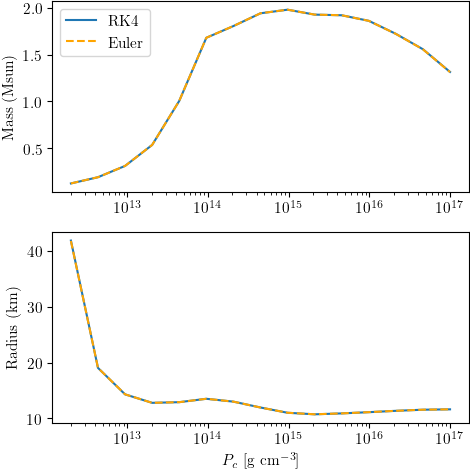

In [231]:
fig, axs = plt.subplots(2, 1, figsize=(5, 5))

# have ax1 and ax2 share x-axis
axs[0].sharex(axs[1])

P_c = P_div_c2_0_arr
axs[0].plot(P_c.to(u.g / u.cm**3), Ms.to(u.Msun), label='RK4')
axs[0].plot(P_c.to(u.g / u.cm**3), Ms_euler.to(u.Msun), linestyle='--', color='orange', label='Euler')
# axs[0].set_xlabel(r"$P_c$ [g cm$^{-3}$]")
axs[0].set_ylabel("Mass (Msun)")
axs[0].legend()

axs[1].plot(P_c.to(u.g / u.cm**3), Rs.to(u.km), label='RK4')
axs[1].plot(P_c.to(u.g / u.cm**3), Rs_euler.to(u.km), linestyle='--', color='orange', label='Euler')
axs[1].set_xscale('log')
axs[1].set_xlabel(r"$P_c$ [g cm$^{-3}$]")
axs[1].set_ylabel("Radius (km)")

plt.tight_layout()
plt.savefig("euler_vs_RK4.png", bbox_inches='tight', dpi=300)
plt.show()

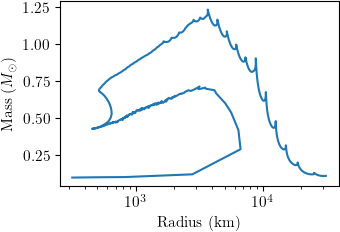

In [98]:
data = np.loadtxt("low_results.csv", skiprows=1, delimiter=",")  # for P_c/c^2 in [1e1, 2e12]

Rs = data[:, 0] * u.km
Ms = data[:, 1] * u.Msun
P_div_c2 = data[:, 2] * (u.g / u.cm**3)

plt.plot(Rs.to(u.km), Ms.to(u.Msun))
plt.xscale('log')
plt.xlabel("Radius (km)")
plt.ylabel(r"Mass ($M_\odot$)")
plt.savefig("WD_branch.png", bbox_inches='tight', dpi=300)
plt.show()